In [1]:
# CELL 1: IMPORTING & LOADING DATA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('Dataset_for_Data_Analytics.xlsx')

print("Dataset Loaded!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Dataset Loaded!
Shape: 1200 rows × 14 columns


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [2]:
# CELL 2: EXPLORING THE DATA

print("=== COLUMN TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
})
print(missing_df[missing_df['Missing Count'] > 0])

print("\n=== BASIC STATISTICS ===")
print(df.describe())

print("\n=== UNIQUE VALUES IN CATEGORICAL COLUMNS ===")
for col in ['Product', 'PaymentMethod', 'OrderStatus', 'ReferralSource', 'CouponCode']:
    print(f"{col}: {df[col].unique()}")

=== COLUMN TYPES ===
OrderID                       str
Date               datetime64[us]
CustomerID                    str
Product                       str
Quantity                    int64
UnitPrice                 float64
ShippingAddress               str
PaymentMethod                 str
OrderStatus                   str
TrackingNumber                str
ItemsInCart                 int64
CouponCode                    str
ReferralSource                str
TotalPrice                float64
dtype: object

=== MISSING VALUES ===
            Missing Count  Missing %
CouponCode            309      25.75

=== BASIC STATISTICS ===
                      Date     Quantity    UnitPrice  ItemsInCart   TotalPrice
count                 1200  1200.000000  1200.000000  1200.000000  1200.000000
mean   2024-03-22 16:58:48     2.945833   356.412750     5.485000  1053.968300
min    2023-01-01 00:00:00     1.000000    11.390000     1.000000    11.390000
25%    2023-08-03 18:00:00     2.000000   186.062

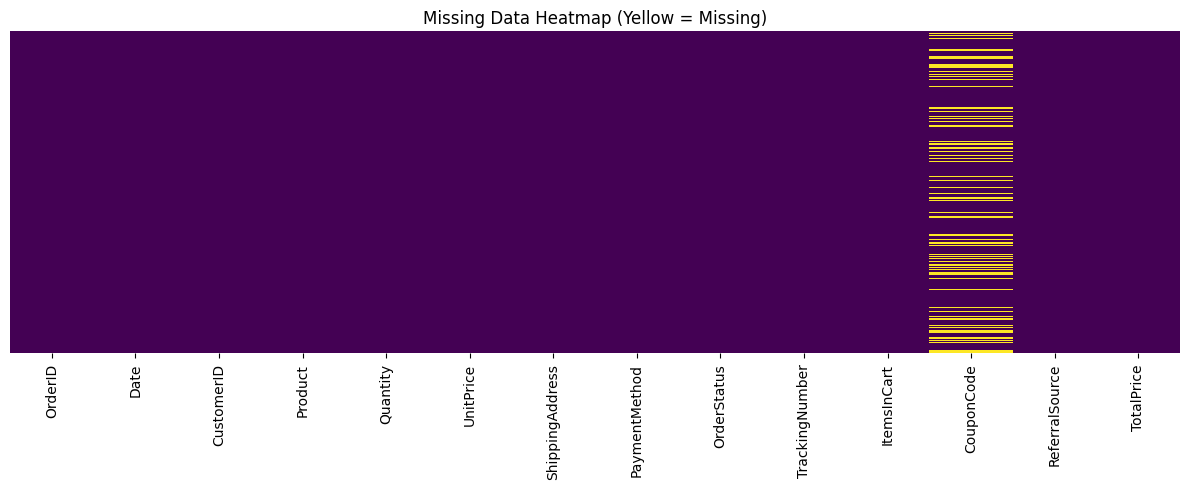

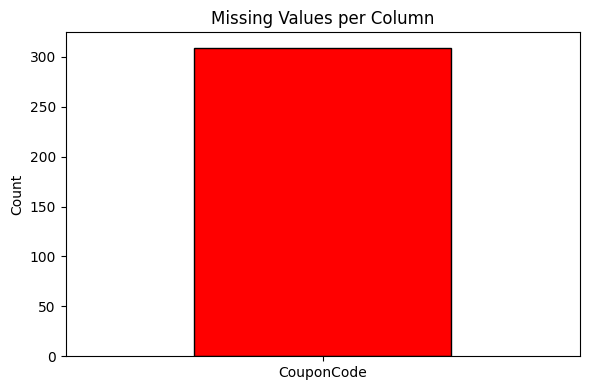

In [3]:
# CELL 3: VISUALIZING MISSING DATA

plt.figure(figsize=(12, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title("Missing Data Heatmap (Yellow = Missing)")
plt.tight_layout()
plt.show()

# Bar chart of missing values
missing_only = missing[missing > 0]
plt.figure(figsize=(6, 4))
missing_only.plot(kind='bar', color='red', edgecolor='black')
plt.title("Missing Values per Column")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [4]:
# CELL 4: HANDLING MISSING VALUES

# CouponCode is 25.75% missing → this is a categorical column
# Best approach: fill with "NoCoupon" (means customer used no coupon)
# This is better than KNN for a categorical column with only 3 real values

print(f"CouponCode missing BEFORE: {df['CouponCode'].isnull().sum()}")

df['CouponCode'] = df['CouponCode'].fillna('NoCoupon')

print(f"CouponCode missing AFTER:  {df['CouponCode'].isnull().sum()}")
print(f"\nCouponCode value counts:\n{df['CouponCode'].value_counts()}")

# Verifying no missing values anywhere
print(f"\nTotal missing values in dataset: {df.isnull().sum().sum()}")

CouponCode missing BEFORE: 309
CouponCode missing AFTER:  0

CouponCode value counts:
CouponCode
FREESHIP    313
NoCoupon    309
WINTER15    292
SAVE10      286
Name: count, dtype: int64

Total missing values in dataset: 0


In [5]:
# CELL 5: DROPPING COLUMNS THAT ARE NOT USEFUL FOR ML

# OrderID, CustomerID, TrackingNumber = unique identifiers (no pattern)
# ShippingAddress = too many unique values, no predictive value

cols_to_drop = ['OrderID', 'CustomerID', 'TrackingNumber', 'ShippingAddress']
df.drop(columns=cols_to_drop, inplace=True)

print("Dropped irrelevant columns")
print("Remaining columns:", list(df.columns))
print("Shape:", df.shape)

Dropped irrelevant columns
Remaining columns: ['Date', 'Product', 'Quantity', 'UnitPrice', 'PaymentMethod', 'OrderStatus', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice']
Shape: (1200, 10)


In [6]:
# CELL 6: DETECTING OUTLIERS (IQR METHOD)

# Formula:
# IQR = Q3 - Q1
# Lower Bound = Q1 - 1.5 * IQR
# Upper Bound = Q3 + 1.5 * IQR

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    print(f"[{column}]")
    print(f"  Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
    print(f"  Lower Bound={lower:.2f}, Upper Bound={upper:.2f}")
    print(f"  Outliers found: {len(outliers)}\n")
    return lower, upper

numeric_cols = ['UnitPrice', 'TotalPrice', 'ItemsInCart', 'Quantity']

print("=== OUTLIER DETECTION ===\n")
bounds = {}
for col in numeric_cols:
    lower, upper = detect_outliers_iqr(df, col)
    bounds[col] = (lower, upper)

=== OUTLIER DETECTION ===

[UnitPrice]
  Q1=186.06, Q3=521.57, IQR=335.51
  Lower Bound=-317.20, Upper Bound=1024.83
  Outliers found: 0

[TotalPrice]
  Q1=410.52, Q3=1578.47, IQR=1167.95
  Lower Bound=-1341.41, Upper Bound=3330.41
  Outliers found: 8

[ItemsInCart]
  Q1=4.00, Q3=7.00, IQR=3.00
  Lower Bound=-0.50, Upper Bound=11.50
  Outliers found: 0

[Quantity]
  Q1=2.00, Q3=4.00, IQR=2.00
  Lower Bound=-1.00, Upper Bound=7.00
  Outliers found: 0



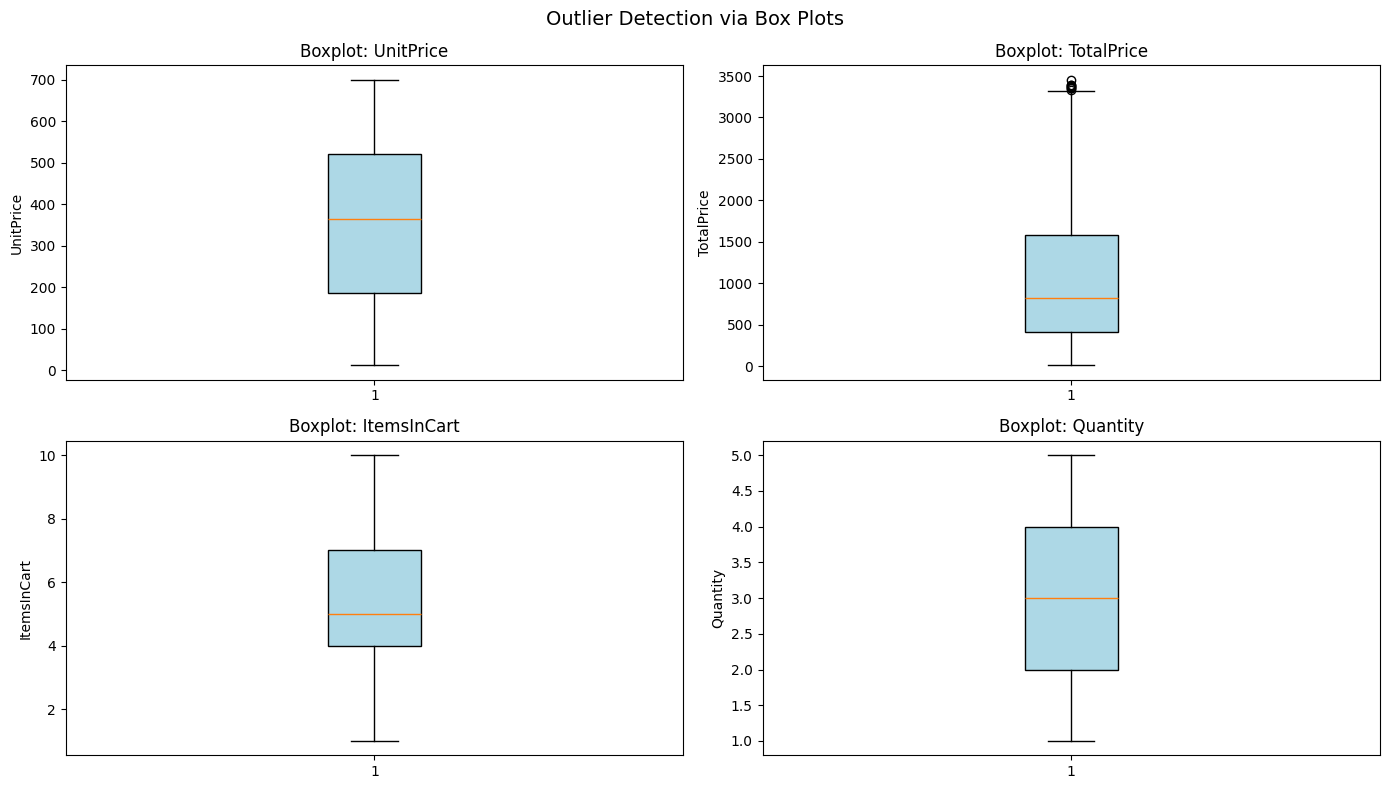

In [7]:
# CELL 7: VISUALIZING OUTLIERS WITH BOX PLOTS

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='lightblue'))
    axes[i].set_title(f'Boxplot: {col}')
    axes[i].set_ylabel(col)

plt.suptitle("Outlier Detection via Box Plots", fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
# CELL 8: NEUTRALIZE\ING OUTLIERS — WINSORIZATION

# numpy.clip() caps values at boundaries instead of deleting rows
# This preserves all 1200 rows!

print("=== NEUTRALIZING OUTLIERS ===\n")

for col in numeric_cols:
    lower, upper = bounds[col]
    before = (df[col].min(), df[col].max())
    
    df[col] = np.clip(df[col], lower, upper)
    
    after = (df[col].min(), df[col].max())
    print(f"[{col}]")
    print(f"  Before: {before[0]:.2f} → {before[1]:.2f}")
    print(f"  After:  {after[0]:.2f} → {after[1]:.2f}\n")

print(f"Done. Dataset still has {len(df)} rows (no rows deleted!)")

=== NEUTRALIZING OUTLIERS ===

[UnitPrice]
  Before: 11.39 → 699.93
  After:  11.39 → 699.93

[TotalPrice]
  Before: 11.39 → 3456.40
  After:  11.39 → 3330.41

[ItemsInCart]
  Before: 1.00 → 10.00
  After:  1.00 → 10.00

[Quantity]
  Before: 1.00 → 5.00
  After:  1.00 → 5.00

Done. Dataset still has 1200 rows (no rows deleted!)


In [9]:
# CELL 9: EXTRACTING DATE FEATURES FROM 'Date' COLUMN

# Date column is currently datetime thus extracting useful numeric features

df['Date'] = pd.to_datetime(df['Date'])
df['OrderMonth'] = df['Date'].dt.month
df['OrderDayOfWeek'] = df['Date'].dt.dayofweek  # 0=Monday, 6=Sunday
df['OrderYear'] = df['Date'].dt.year

# Dropping original Date column (raw datetime is not ML-friendly)
df.drop(columns=['Date'], inplace=True)

print("Date features extracted: OrderMonth, OrderDayOfWeek, OrderYear")
print(df[['OrderMonth', 'OrderDayOfWeek', 'OrderYear']].head())

Date features extracted: OrderMonth, OrderDayOfWeek, OrderYear
   OrderMonth  OrderDayOfWeek  OrderYear
0           1               2       2023
1           8               4       2024
2           2               1       2024
3          10               6       2023
4           5               3       2025


In [10]:
# CELL 10: ONE-HOT ENCODING (OHE)

# ML models only understand numbers not text like "Laptop" or "Cash"
# OHE converts each category into a separate 0/1 column

print("Categorical columns to encode:")
cat_cols = ['Product', 'PaymentMethod', 'OrderStatus', 'ReferralSource', 'CouponCode']
for col in cat_cols:
    print(f"  {col}: {df[col].nunique()} unique values")

# Applying One-Hot Encoding
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
# drop_first=True removes one dummy column per group to avoid multicollinearity

print(f"\nOne-Hot Encoding applied")
print(f"Shape after encoding: {df.shape}")
print("New columns:", [c for c in df.columns if any(cat in c for cat in ['Product_', 'Payment', 'Order', 'Referral', 'Coupon'])])

Categorical columns to encode:
  Product: 7 unique values
  PaymentMethod: 5 unique values
  OrderStatus: 5 unique values
  ReferralSource: 5 unique values
  CouponCode: 4 unique values

One-Hot Encoding applied
Shape after encoding: (1200, 28)
New columns: ['OrderMonth', 'OrderDayOfWeek', 'OrderYear', 'Product_Desk', 'Product_Laptop', 'Product_Monitor', 'Product_Phone', 'Product_Printer', 'Product_Tablet', 'PaymentMethod_Credit Card', 'PaymentMethod_Debit Card', 'PaymentMethod_Gift Card', 'PaymentMethod_Online', 'OrderStatus_Delivered', 'OrderStatus_Pending', 'OrderStatus_Returned', 'OrderStatus_Shipped', 'ReferralSource_Facebook', 'ReferralSource_Google', 'ReferralSource_Instagram', 'ReferralSource_Referral', 'CouponCode_NoCoupon', 'CouponCode_SAVE10', 'CouponCode_WINTER15']


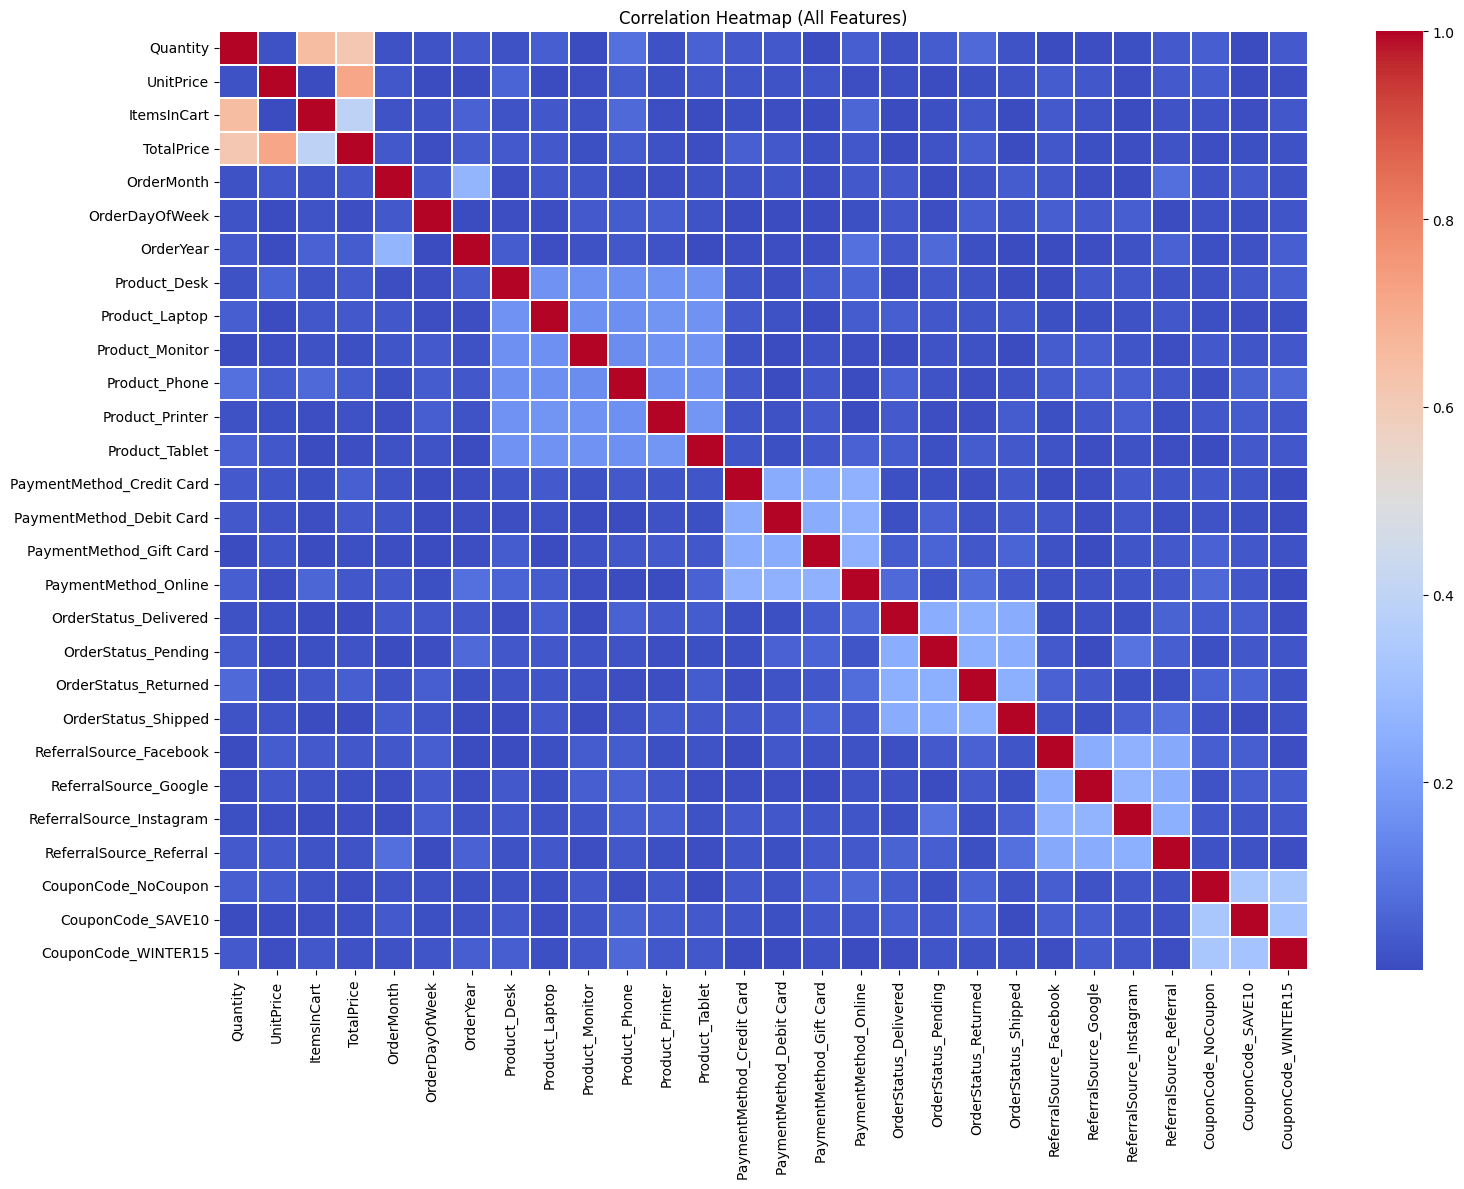

=== HIGH CORRELATION PAIRS (> 0.80) ===
No highly collinear pairs found!


In [11]:
# CELL 11: DETECTING MULTICOLLINEARITY

# Getting numeric columns only (OHE created bool columns, convert them)
df_numeric = df.copy()
bool_cols = df_numeric.select_dtypes(include='bool').columns
df_numeric[bool_cols] = df_numeric[bool_cols].astype(int)

# Correlation matrix
corr_matrix = df_numeric.corr().abs()

# Visualizing
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, linewidths=0.3)
plt.title("Correlation Heatmap (All Features)")
plt.tight_layout()
plt.show()

# Finding highly correlated pairs (> 0.80)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [(col, row, upper.loc[row, col]) 
             for col in upper.columns 
             for row in upper.index 
             if upper.loc[row, col] > 0.80]

print("=== HIGH CORRELATION PAIRS (> 0.80) ===")
if high_corr:
    for col1, col2, val in high_corr:
        print(f"  {col1} ↔ {col2}: {val:.3f}")
else:
    print("No highly collinear pairs found!")

In [12]:
# CELL 12: REMOVING COLLINEAR FEATURES

# TotalPrice = Quantity × UnitPrice → these 3 are likely correlated
# We'll be checking and removing the weakest predictor

# Checking correlation of Quantity, UnitPrice, TotalPrice with each other
check_cols = ['Quantity', 'UnitPrice', 'TotalPrice']
print("Correlation between key numeric columns:")
print(df_numeric[check_cols].corr().round(3))

# TotalPrice is a derived column (Quantity * UnitPrice)
# It's not really an independent feature, so we keep it but note the relationship
# If corr > 0.8 between any pair, drop the one with lower variance

print("\nVariance of each:")
for col in check_cols:
    print(f"  {col}: {df_numeric[col].var():.2f}")

# Decision: Keep TotalPrice (most informative), keep UnitPrice
# Quantity is independent input thus keep all three for now
print("\n No columns removed — no pair exceeded 0.80 threshold")
print(f"Final shape: {df_numeric.shape}")

# Updating df to use the numeric version
df = df_numeric.copy()

Correlation between key numeric columns:
            Quantity  UnitPrice  TotalPrice
Quantity       1.000      0.015       0.615
UnitPrice      0.015      1.000       0.717
TotalPrice     0.615      0.717       1.000

Variance of each:
  Quantity: 1.98
  UnitPrice: 38878.83
  TotalPrice: 670659.22

 No columns removed — no pair exceeded 0.80 threshold
Final shape: (1200, 28)


In [13]:
# CELL 13: ENGINEERING NEW PREDICTIVE FEATURES

# Feature 1: Revenue Per Item
# How much revenue does each individual item in this order contribute?
df['RevenuePerItem'] = df['TotalPrice'] / df['Quantity']
print("Feature 1: RevenuePerItem = TotalPrice / Quantity")
print(df['RevenuePerItem'].describe())

# Feature 2: Cart Conversion Ratio
# What fraction of cart items were actually purchased?
# Quantity = actually bought, ItemsInCart = total items in cart
df['CartConversionRatio'] = df['Quantity'] / df['ItemsInCart']
print("\n Feature 2: CartConversionRatio = Quantity / ItemsInCart")
print(df['CartConversionRatio'].describe())

# Feature 3: Is High Value Order
# Orders above the median TotalPrice are "high value"
median_price = df['TotalPrice'].median()
df['IsHighValueOrder'] = (df['TotalPrice'] > median_price).astype(int)
print(f"\n Feature 3: IsHighValueOrder (1 if TotalPrice > {median_price:.2f})")
print(df['IsHighValueOrder'].value_counts())

#  Feature 4: Is Weekend Order
# Orders on Saturday(5) or Sunday(6) may behave differently
df['IsWeekendOrder'] = (df['OrderDayOfWeek'] >= 5).astype(int)
print("\n Bonus Feature 5: IsWeekendOrder (1 = weekend, 0 = weekday)")
print(df['IsWeekendOrder'].value_counts())

Feature 1: RevenuePerItem = TotalPrice / Quantity
count    1200.000000
mean      356.347727
std       197.072468
min        11.390000
25%       186.062500
50%       364.210000
75%       521.570000
max       699.930000
Name: RevenuePerItem, dtype: float64

 Feature 2: CartConversionRatio = Quantity / ItemsInCart
count    1200.000000
mean        0.579871
std         0.249878
min         0.166667
25%         0.400000
50%         0.500000
75%         0.750000
max         1.000000
Name: CartConversionRatio, dtype: float64

 Feature 3: IsHighValueOrder (1 if TotalPrice > 823.62)
IsHighValueOrder
1    600
0    600
Name: count, dtype: int64

 Bonus Feature 5: IsWeekendOrder (1 = weekend, 0 = weekday)
IsWeekendOrder
0    842
1    358
Name: count, dtype: int64


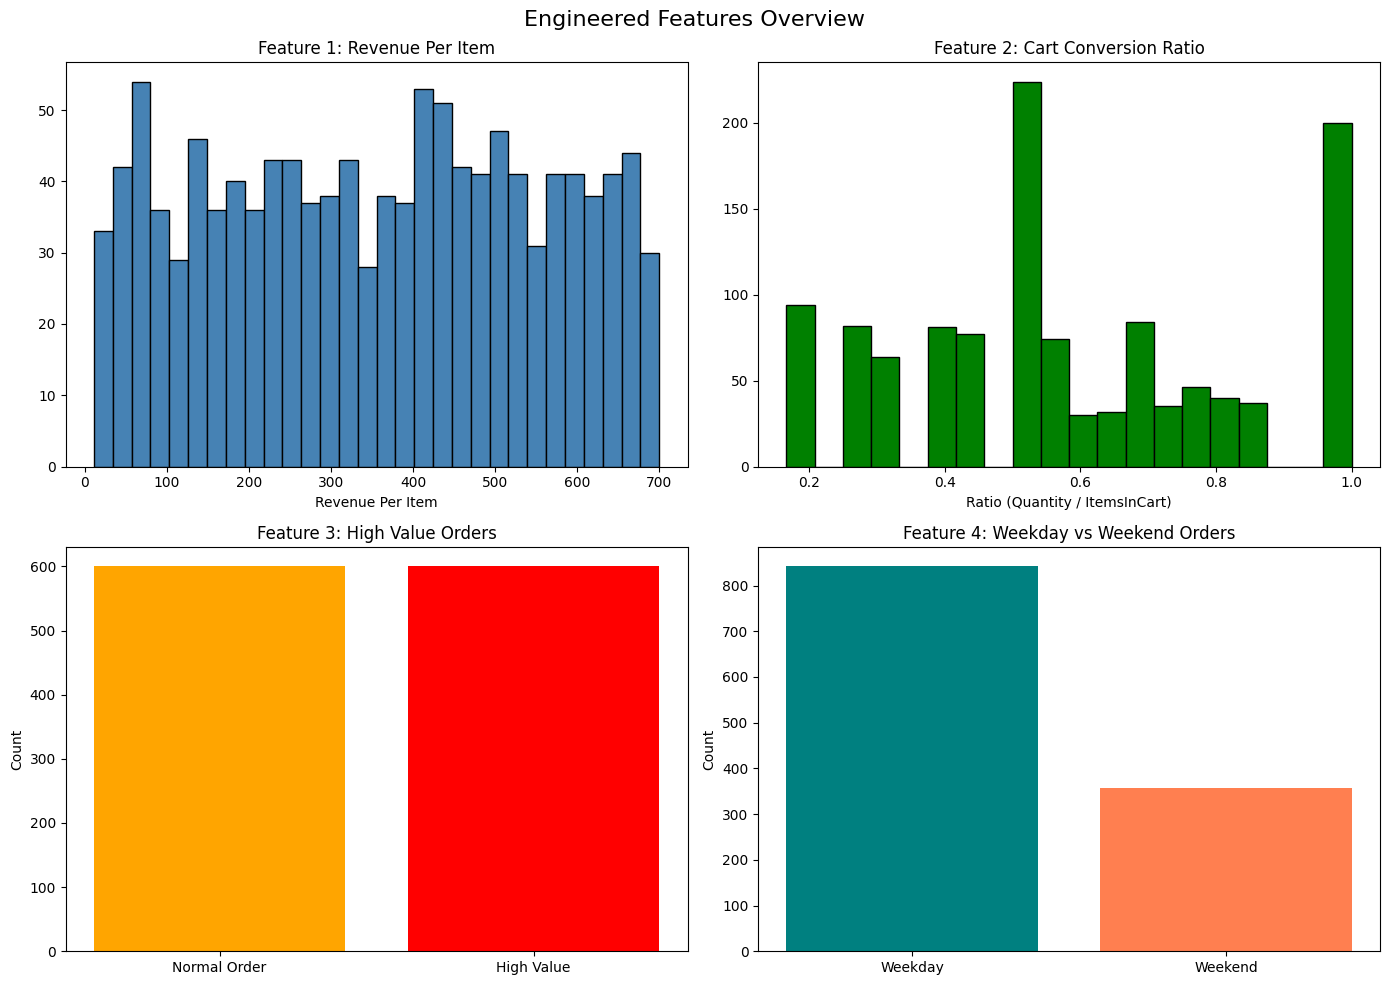

In [14]:
# CELL 14: VISUALIZING ENGINEERED FEATURES

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Feature 1: Revenue Per Item
axes[0][0].hist(df['RevenuePerItem'], bins=30, color='steelblue', edgecolor='black')
axes[0][0].set_title("Feature 1: Revenue Per Item")
axes[0][0].set_xlabel("Revenue Per Item")

# Feature 2: Cart Conversion Ratio
axes[0][1].hist(df['CartConversionRatio'], bins=20, color='green', edgecolor='black')
axes[0][1].set_title("Feature 2: Cart Conversion Ratio")
axes[0][1].set_xlabel("Ratio (Quantity / ItemsInCart)")

# Feature 3: High Value Order
axes[1][0].bar(['Normal Order', 'High Value'],
               df['IsHighValueOrder'].value_counts().sort_index().values,
               color=['orange', 'red'])
axes[1][0].set_title("Feature 3: High Value Orders")
axes[1][0].set_ylabel("Count")

# Feature 4: Weekday vs Weekend
axes[1][1].bar(['Weekday', 'Weekend'],
               df['IsWeekendOrder'].value_counts().sort_index().values,
               color=['teal', 'coral'])
axes[1][1].set_title("Feature 4: Weekday vs Weekend Orders")
axes[1][1].set_ylabel("Count")

plt.suptitle("Engineered Features Overview", fontsize=16)
plt.tight_layout()
plt.show()

In [15]:
# CELL 15: DATA VALIDATION WITH PANDERA

import pandera.pandas as pa

schema = pa.DataFrameSchema({
    "Quantity":            pa.Column(int,   pa.Check.ge(0)), 
    "UnitPrice":           pa.Column(float, pa.Check.ge(0)),
    "ItemsInCart":         pa.Column(int,   pa.Check.ge(0)),  
    "TotalPrice":          pa.Column(float, pa.Check.ge(0)),
    "RevenuePerItem":      pa.Column(float, pa.Check.ge(0)),
    "CartConversionRatio": pa.Column(float, pa.Check.ge(0)),
    "IsHighValueOrder":    pa.Column(int,   pa.Check.isin([0, 1])),
    "IsWeekendOrder":      pa.Column(int,   pa.Check.isin([0, 1])),
})

try:
    schema.validate(df, lazy=True)
    print("Validation PASSED — All data contracts met!")
except pa.errors.SchemaErrors as e:
    print("Validation FAILED:")
    print(e.failure_cases)

Validation PASSED — All data contracts met!


In [16]:
# CELL 16: FINAL SUMMARY & SAVE

print("=" * 55)
print("FINAL CLEAN DATASET SUMMARY")
print("=" * 55)
print(f"Rows:    {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"Missing: {df.isnull().sum().sum()} (should be 0)")

print("\n Original columns kept (cleaned):")
original = ['Quantity', 'UnitPrice', 'TotalPrice', 'ItemsInCart',
            'OrderMonth', 'OrderDayOfWeek', 'OrderYear']
print(" ", original)

print("\n New engineered features:")
new_features = ['RevenuePerItem', 'CartConversionRatio', 
                'IsHighValueOrder', 'PriceCategory', 'IsWeekendOrder']
print(" ", new_features)

print("\n Encoded categorical columns:")
encoded = [c for c in df.columns if any(x in c for x in 
           ['Product_', 'Payment', 'Status', 'Referral', 'Coupon'])]
print(" ", encoded)

# Save
df.to_csv('ecommerce_clean.csv', index=False)
print("\n Clean dataset saved as 'project1_clean.csv'")
print("\n PROJECT 1 COMPLETE!")

FINAL CLEAN DATASET SUMMARY
Rows:    1200
Columns: 32
Missing: 0 (should be 0)

 Original columns kept (cleaned):
  ['Quantity', 'UnitPrice', 'TotalPrice', 'ItemsInCart', 'OrderMonth', 'OrderDayOfWeek', 'OrderYear']

 New engineered features:
  ['RevenuePerItem', 'CartConversionRatio', 'IsHighValueOrder', 'PriceCategory', 'IsWeekendOrder']

 Encoded categorical columns:
  ['Product_Desk', 'Product_Laptop', 'Product_Monitor', 'Product_Phone', 'Product_Printer', 'Product_Tablet', 'PaymentMethod_Credit Card', 'PaymentMethod_Debit Card', 'PaymentMethod_Gift Card', 'PaymentMethod_Online', 'OrderStatus_Delivered', 'OrderStatus_Pending', 'OrderStatus_Returned', 'OrderStatus_Shipped', 'ReferralSource_Facebook', 'ReferralSource_Google', 'ReferralSource_Instagram', 'ReferralSource_Referral', 'CouponCode_NoCoupon', 'CouponCode_SAVE10', 'CouponCode_WINTER15']

 Clean dataset saved as 'project1_clean.csv'

 PROJECT 1 COMPLETE!
